In [1]:
# Latex macros -- ignore
from IPython.display import display, Math
with open('macros.tex', 'r') as f:
        macros = f.read()
display(Math(macros))

<IPython.core.display.Math object>

In [2]:
from IPython.display import Latex
def showState(label, state):
    stateSource = state.draw("latex_source")
    display(Latex(label + " $= " + stateSource + "$"))

# Deutsch-Jozsa algorithm
* A Boolean function  $f : \{0,1\}^n\to \{0, 1\}$
* A constant Boolean function  $$c_0(x) = 0$$ $$c_1(x) = 1$$ for all $x\in \{0,1\}^n$
    * There are only two constant Boolean functions.
* A balanced Boolean function $$b(x) = \begin{cases}0 & x\in A\subset \{0,1\}^n\\ 1 & x\in B\subset \{0, 1\}^n\end{cases}$$ where $A\cap B =\emptyset$ and $|A|=|B|=\frac{2^n}{2}$.
    * In another words, $b$ partitions the set of inputs $\{0,1\}^n$ into two equal parts $A, B$ such that $A$ is mapped to 0 and $B$ is mapped to 1.
    * There are $2^n\choose 2^{n-1}$ balanced Boolean functions.
    * It may seem a large number, but picking a balanced function at random has very low probability.
    * Constructing balanced Boolean functions is very significant task in cryptography.
## Task:
* Fix $n$ and $N = 2^n$. 
* Let $\mathcal{C}$ be the set of constant Boolean functions and $\mathcal{B}$ be the set of balanced Boolean functions.
* One of the sets $\mathcal{C}$ or $\mathcal{B}$ are chosen at random.
* A function $f$ is chosen from the chosen set.
* It is possible to evaluate $f$ at any input $x$, i.e. we can query $f$.
* The task is to determine whether $f\in \mathcal{C}$ or $f\in \mathcal{B}$ using as few queries to $f$.
## Classical algorithms:
### Deterministic strategy
* It requires querying $f$ at least $\frac{N}{2} + 1$ times.
### Probabilitic strategy
* For probability of error $\epsilon < 1/2$, we need to make 3 queries to $f$.
## Quantum algorithm:
* One query to $f$ and no error.


## Quantum strategy
* We need a quantum oracle for querying $f$.
    * It will be implemented as a unitary operator $U_f$ $$|x\rangle|y\rangle\xrightarrow{U_f}|x\rangle|y\oplus f(x)\rangle$$
    * Check that $|x\rangle|-\rangle$ are eigenvectors of the operator $U_f$: $$U_f|x\rangle|-\rangle = (-1)^{f(x)}|x\rangle|-\rangle$$
* The input should be equal superposition of all inputs $x$: $$|\psi\rangle = \frac{1}{\sqrt{N}}\sum_x|x\rangle$$
* Output should be such that measurement leads to orthogonal states.

### Preparing the input
* Single qubit: Hadamard gate prepares basis states into equal superposition states for $x\in\{0,1\}$ $$H|x\rangle = \frac{1}{\sqrt{2}}\sum_{z=0}^1(-1)^{xz}|z\rangle$$
* Multiple qubits: Fon $x\in\{0,1\}^n$ $$H^{\otimes n}|x\rangle = \frac{1}{\sqrt{N}}\sum_{z\in\{0,1\}^n}(-1)^{x\cdot z}|z\rangle$$
* We can start with $n + 1$ qubits: $n$ for input and 1 for output. $$H^{\otimes n}|0^{\otimes n}\rangle\otimes HX|0\rangle = \frac{1}{\sqrt{N}}\sum_x|x\rangle|-\rangle$$

In [3]:
from qiskit.circuit import QuantumCircuit
import numpy as np

In [4]:
def Hn(n):
    qc = QuantumCircuit(n)
    qc.h(range(n))
    lab = "$H^n$"
    hn = qc.to_gate(label=lab)
    hn.name = "Hn"
    hn.definition = qc
    return hn

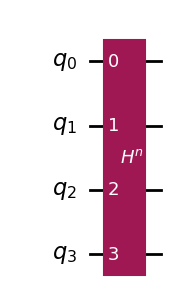

In [5]:
temp = QuantumCircuit(4)
t1 = temp.compose(Hn(4))
t1.draw("mpl")

## Constructing the Oracle $U_f$ for constant function
* This is the easy part, just let input $x$ pass.
* Choose the target bit to be 0 or 1 by applying not gate to it at random.

In [6]:
def constant(num_qubits):
    qc = QuantumCircuit(num_qubits + 1)
    if np.random.randint(0, 2):
        # Flip output qubit with 50% chance
        qc.x(num_qubits)
    return qc

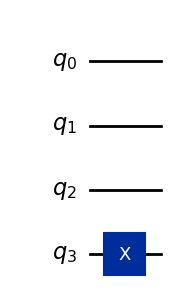

4

In [7]:
display(constant(3).draw("mpl"))
display(constant(3).num_qubits)

## Constructing the Oracle $U_f$ for balanced function
* Partition $\{0,1\}^n$ into equal parts $A, B$ at random.
* Say $A$ is mapped to 1
* For each $x\in A$, apply $X$ gates to qubits such that $x\to 1^{n}$ and acts as a control that flips 0 to 1 on the target bit.
* Then apply the multi-control $X$ on target bit
* Undo changes to $x$ by applying the same sequence of $Xs$.
* This is very inefficient--requires $2^{n-1}$ layers.

In [8]:
from qiskit.quantum_info import Statevector
def balanced(num_qubits):
    qc = QuantumCircuit(num_qubits + 1)
    # Apply not gate to target bit at random 
    if np.random.randint(0, 2):
        # Flip output qubit with 50% chance
        qc.x(num_qubits)
    # Choose half the possible input strings
    on_states = np.random.choice(
        range(2**num_qubits),  # numbers to sample from
        2**num_qubits // 2,  # number of samples
        replace=False,  # makes sure states are only sampled once
    )
    print(on_states)
    def add_cx(qc, bit_string):
        for qubit, bit in enumerate(reversed(bit_string)):
            if bit == "1":
                qc.x(qubit)
        return qc

    for state in on_states:
        # qc.barrier()  # Barriers are added to help visualize how the functions are created.
        qc = add_cx(qc, f"{state:0b}")
        qc.mcx(list(range(num_qubits)), num_qubits)
        qc = add_cx(qc, f"{state:0b}")

    # qc.barrier()
    display(Statevector(qc).draw("latex"))
    return qc

[3 7 2 0]


<IPython.core.display.Latex object>

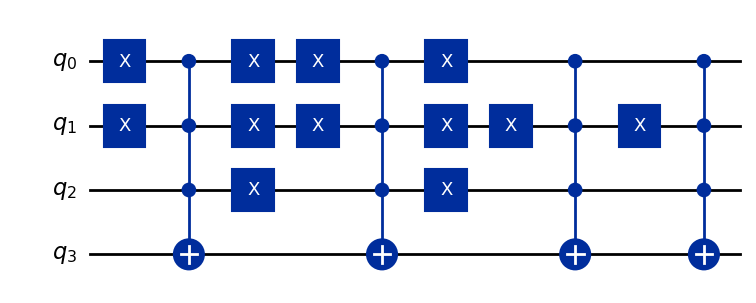

In [9]:
balanced(3).draw("mpl")

## Deutsch Oracle
* Choose constant or balanced functions sets at random.
* Use the appropriate oracle for $f$


In [10]:
def deutschOracle(num_qubits):
    if np.random.randint(0, 2):
        qc = constant(num_qubits)
    else:
        qc = balanced(num_qubits)
    display(qc.draw("mpl"))
    uf_gate = qc.to_gate(label="$U_f$")
    uf_gate.name = "oracle"
    return uf_gate

[2 6 1 5]


<IPython.core.display.Latex object>

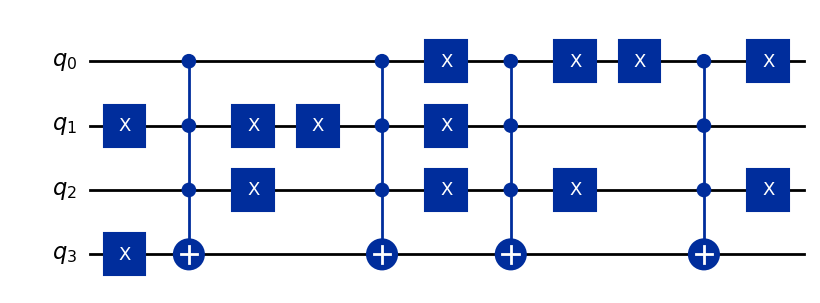

4

In [11]:
U_f = deutschOracle(3)
display(U_f.num_qubits)
# display(Uc.draw("mpl"))
# U_f = Uc.to_gate(label="U_f")

## Circuit

In [12]:
from qiskit.quantum_info import Statevector
def deutsch_circuit(oracle):
    n = oracle.num_qubits - 1
    qc = QuantumCircuit(n + 1, n)
    qc.x(n)
    qc.h(n)
    hn = Hn(n)
    qc.compose(hn, inplace=True)
    qc.compose(oracle, inplace=True)
    qc.compose(hn, inplace=True)
    qc.h(n)
    psi = Statevector(qc)
    qc.measure(range(n), range(n))
    return [qc, psi]

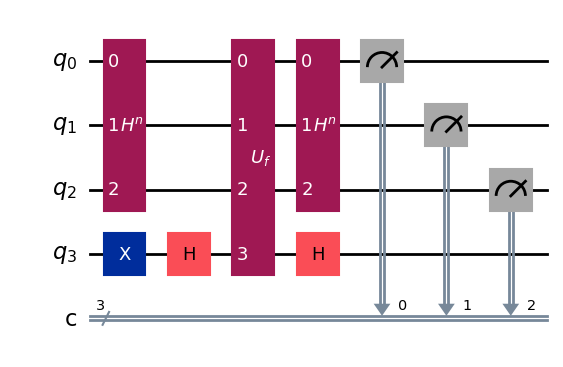

<IPython.core.display.Latex object>

In [13]:
dc = deutsch_circuit(U_f)
display(dc[0].draw("mpl"))
display(dc[1].draw("latex"))

In [19]:
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit import transpile
def deutschJozsaAlgo(num_qubits):
    oracle = deutschOracle(num_qubits)
    [qc, psi] = deutsch_circuit(oracle)
    display(psi.draw("latex"))
    display(qc.draw("mpl"))
    
    #----Measurement Simulation----
    sim = AerSimulator()
    t_qc = transpile(qc, sim)
    result = sim.run(t_qc, shots=1, memory=True).result()
    measurements = result.get_memory()
    if "1" in measurements[0]:
        return "balanced"
    else:
        return "constant"
    

[4 1 2 0]


<IPython.core.display.Latex object>

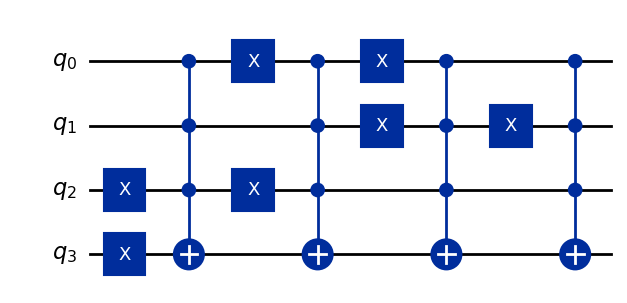

<IPython.core.display.Latex object>

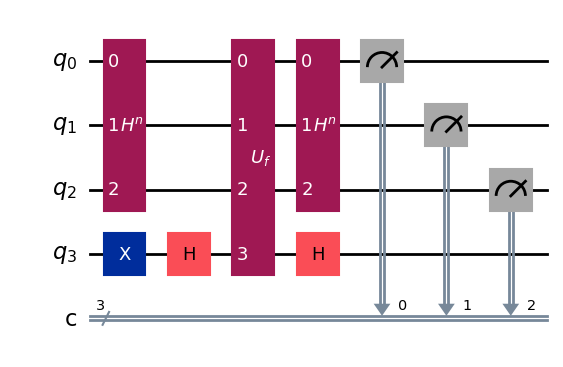

'balanced'

In [20]:
deutschJozsaAlgo(3)